In [1]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib as mpl
import scipy.integrate as integ
#from functions import *

import requests
request = requests.get("https://raw.githubusercontent.com/nsfuss/AMOC-Senior-Project/refs/heads/main/functions.py")
with open("functions.py", "wb") as f:
  f.write(request.content)

from functions import *

mpl.rc('xtick', direction='in', top=True)
mpl.rc('ytick', direction='in', right=True)
mpl.rc('xtick.minor', visible=True)
mpl.rc('ytick.minor', visible=True)


## Goal:

Have H increase linearly w.r.t time and then decrease linearly w.r.t time, graph Q vs T for this scenario. It is unlikely we will see the expected spike as H decreases to the critical point. <br>
 
Now let $q$ be defined by the differential $\tau \frac{dq}{dt} = -q + k|\alpha \Delta T - \beta \Delta S|$ integrate this to get q as H increases given the known relationship $\frac{d \Delta S}{dt} = 2H - 2|q| \Delta S$ <br>
Need to figure out what $\tau$ should be here, Cyrus guesses in the range of 1-2 centuries

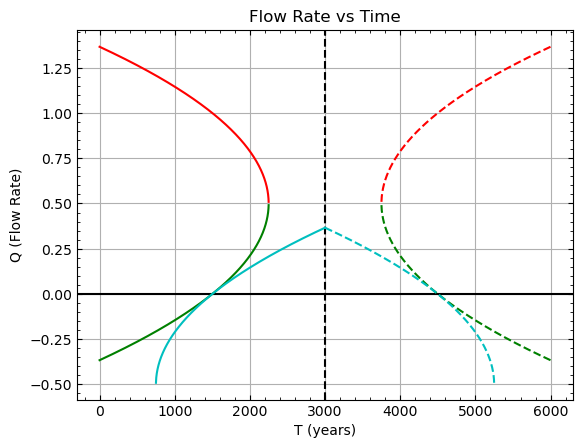

In [113]:
beta = 0.5
alpha = 2
delT = 1
k = 0.5
Args = [beta,alpha,delT,k] # Define arguments

q0, q1, q2, times = q_H2(Args, -2, 2, 6000)


plt.axhline(0, color='k')
plt.axvline(3000,color='k',ls='--')
# Graphing the increasing and decreasing sections of 
plt.plot(times[0], q0[0] , color='r',label='First Stable Inc')
plt.plot(times[1], q0[1] , color='r',ls='--',label='First Stable Dec')

plt.plot(times[2], q1[0], color='g',label='Unstable Inc')
plt.plot(times[3], q1[1], color='g',ls='--',label='Unstable Dec')

plt.plot(times[4], q2[0], color='c',label='Second Stable Inc')
plt.plot(times[5], q2[1], color='c',ls='--',label='Second Stable Dec')

#plt.xlim(1200,2000)
plt.title('Flow Rate vs Time')
plt.xlabel('T (years)')
plt.ylabel('Q (Flow Rate)')
plt.grid()
#plt.legend()



## Redefining $q$ as $q(t)$

This means resolving the system but now instead of just $\Delta S$ being a function of time, $q$ is now also a function of time. 




In [102]:
def dqdtTest(t, y, args, n, H_start, H_end):
    '''
    System of equation for AMOC with q, DS, and H as functions of time

    Parameters:
    t: float, time
    y: array of DS, q, and H: y[0]=DS, y[1]=q, y[2]=H
    args: array: [beta, alpha, delT, k]
    n: intended number of samples

    Output:
    dydt: array same shape as y where dydt[i] is the time derivative of y[i]
    '''
    dydt = np.zeros_like(y)
    dydt[0] = 2 * y[2] - 2 * np.absolute(y[1]) * y[0]
    dydt[1] = (-y[1] + args[3] * np.absolute(args[1]*args[2] - args[0]*y[0])) / 200
    if t < n/2:
        dydt[2] = (H_end - H_start) / (n /2)
    elif t > n/2:
        dydt[2] = -(H_end - H_start) / (n /2)
    
    return dydt

In [114]:
n = 6000
H_start = -2
H_end = 2
qinital = q0[0][0]
DSinitial = dSi0 = Args[1]*Args[2] * (1/2 - np.sqrt(1/4 - H_start*Args[0]/(Args[3]*(Args[1]**2)*(Args[2]**2)))) / Args[0]

y0 = np.array([DSinitial, qinital, H_start])

sol = integ.solve_ivp(dqdtTest,(0,n),y0,atol=1e-12, rtol=1e-12, args=([Args, n, H_start, H_end]), t_eval=(np.arange(n)))
print(sol.y)

[[-1.46410162 -1.46345972 -1.46250645 ... -1.49666097 -1.497432
  -1.49820286]
 [ 1.3660254   1.36602509  1.3660237  ...  1.33337775  1.33358166
   1.33378552]
 [-2.         -1.99866667 -1.99733333 ... -1.996      -1.99733333
  -1.99866667]]


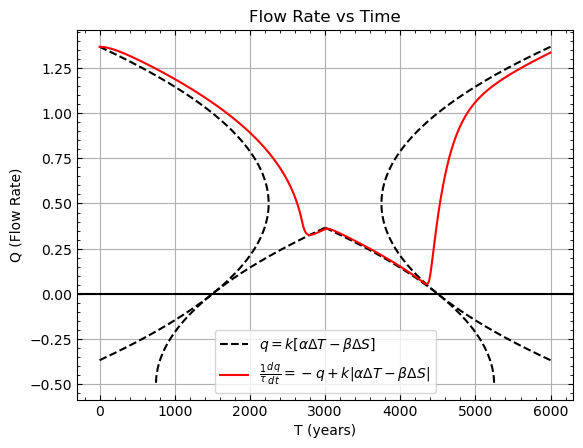

In [115]:


plt.axhline(0, color='k')
# Graphing the increasing and decreasing sections of calculations done with q = |

plt.plot(times[0], q0[0] , color='k',ls='--',label=r'$q=k[\alpha \Delta T - \beta \Delta S]$')
plt.plot(times[1], q0[1] , color='k',ls='--')
plt.plot(times[2], q1[0], color='k',ls='--')
plt.plot(times[3], q1[1], color='k',ls='--')
plt.plot(times[4], q2[0], color='k',ls='--')
plt.plot(times[5], q2[1], color='k',ls='--')

plt.plot(sol.t, sol.y[1], color = 'r',label=r'$\frac{1}{\tau} \frac{dq}{dt}=-q + k|\alpha \Delta T - \beta \Delta S|$')
#plt.xlim(1200,2000)
plt.title('Flow Rate vs Time')
plt.xlabel('T (years)')
plt.ylabel('Q (Flow Rate)')
plt.legend()
plt.grid()
#plt.legend()
